# ASAP-AES : Automated Essay Scoring avec DeBERTa & CORN

**Objectif** : Prédire automatiquement le score (0-3) de réponses courtes d'étudiants

**Approche** :
- **Entraînement par question** (un modèle par EssaySet)
- **Deux architectures** : DeBERTa-v3-small fine-tuné + CORN (régression ordinale)
- **Métriques** : Quadratic Weighted Kappa (QWK) + Accuracy
- **Comparaison détaillée** avec graphiques de performance

**Dataset** : ASAP-SAS (Automated Student Assessment Prize - Short Answer Scoring)

---


## **1. Installation et imports**


In [ ]:
# Installation des packages nécessaires
!pip install -q transformers sentence-transformers torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm

print('Packages installés')


Packages installés


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')


Device: cuda
PyTorch version: 2.10.0+cu128


## **2. Fonctions utilitaires**


In [ ]:
def quadratic_weighted_kappa(y_true, y_pred):
    """Calcule le QWK (Cohen's Quadratic Weighted Kappa)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    min_r = min(y_true.min(), y_pred.min())
    max_r = max(y_true.max(), y_pred.max())
    n = int(max_r - min_r + 1)

    conf = np.zeros((n, n))
    for t, p in zip(y_true, y_pred):
        conf[int(t - min_r), int(p - min_r)] += 1

    w = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            w[i, j] = ((i - j) ** 2) / ((n - 1) ** 2)

    ht = conf.sum(axis=1)
    hp = conf.sum(axis=0)
    exp = np.outer(ht, hp)

    conf /= conf.sum()
    exp /= exp.sum()

    return 1 - (w * conf).sum() / (w * exp).sum()


def clear_memory():
    """Libère la mémoire GPU et RAM."""
    gc.collect()
    torch.cuda.empty_cache()


print('Fonctions utilitaires définies')


Fonctions utilitaires définies


## **3. Chargement et exploration des données**


In [ ]:
from google.colab import files

# Upload du fichier
#uploaded = files.upload()
df = pd.read_csv("/content/dataset_final.csv", encoding='utf-8')

print(f'Dataset chargé: {df.shape[0]} réponses, {df.shape[1]} colonnes')
print(f'Colonnes: {list(df.columns)}')
df.head()


Dataset chargé: 39474 réponses, 4 colonnes
Colonnes: ['id', 'EssaySet', 'Score1', 'EssayText']


,id,EssaySet,Score1,EssayText
0,1673.0,1,1,The procedures I think they should have includ...
1,1674.0,1,1,"In order to replicate this experiment, you wou..."
2,1675.0,1,3,"In order to replicate their experiment, you wo..."
3,1676.0,1,0,Pleace a simple of one material into one conta...
4,1677.0,1,0,Determin the mass of four different samples ma...


In [ ]:
# Exploration rapide
print('Distribution des EssaySets:')
print(df['EssaySet'].value_counts().sort_index())

print('\n Distribution des scores (Score1):')
print(df['Score1'].value_counts().sort_index())

print('\n Nombre de classes par EssaySet:')
for es in sorted(df['EssaySet'].unique()):
    classes = sorted(df[df['EssaySet']==es]['Score1'].unique())
    print(f'  EssaySet {es:2d}: {classes}')


Distribution des EssaySets:
EssaySet
1     3901
2     2982
3     4105
4     3690
5     4188
6     4193
7     4197
8     4197
9     4195
10    3826
Name: count, dtype: int64

 Distribution des scores (Score1):
Score1
0    15563
1    12781
2     9396
3     1734
Name: count, dtype: int64

 Nombre de classes par EssaySet:
  EssaySet  1: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  2: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  3: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  4: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  5: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  6: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  7: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  8: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  9: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet 10: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
# ── Nettoyage léger ──
def clean_text(text):
    text = str(text).lower().strip()
    return ' '.join(text.split())  # Normaliser espaces

df['essay_text'] = df['EssayText'].apply(clean_text)
df['score'] = df['Score1']
df['essay_set'] = df['EssaySet']

# Garder seulement les colonnes nécessaires
df = df[['essay_set', 'essay_text', 'score']].copy()

print(f'Données nettoyées: {df.shape}')
df.head()


Données nettoyées: (39474, 3)


,essay_set,essay_text,score
0,1,the procedures i think they should have includ...,1
1,1,"in order to replicate this experiment, you wou...",1
2,1,"in order to replicate their experiment, you wo...",3
3,1,pleace a simple of one material into one conta...,0
4,1,determin the mass of four different samples ma...,0


In [ ]:
# ── Split stratifié par EssaySet (70/15/15) ──
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['essay_set'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['essay_set'])

print(f'Split effectué:')
print(f'  Train: {len(df_train):5d} ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Val  : {len(df_val):5d} ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test : {len(df_test):5d} ({len(df_test)/len(df)*100:.1f}%)')

# Vérifier stratification
print('\n📊 Distribution par EssaySet:')
for name, dset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    sets = sorted(dset['essay_set'].unique())
    print(f'  {name:5s}: {sets}')


Split effectué:
  Train: 27631 (70.0%)
  Val  :  5921 (15.0%)
  Test :  5922 (15.0%)

📊 Distribution par EssaySet:
  Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Val  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## **4. Feature engineering avec Sentence-BERT**


In [ ]:
# Charger SBERT
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('SBERT chargé (dimension: 384)')

# ── Encoder les ensembles ──
print('\n Encodage des textes...')
train_embeddings = sbert.encode(df_train['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
val_embeddings = sbert.encode(df_val['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
test_embeddings = sbert.encode(df_test['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)

print(f'\n Embeddings générés:')
print(f'  Train: {train_embeddings.shape}')
print(f'  Val  : {val_embeddings.shape}')
print(f'  Test : {test_embeddings.shape}')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

SBERT chargé (dimension: 384)

 Encodage des textes...


Batches:   0%|          | 0/864 [00:00<?, ?it/s]

Batches:   0%|          | 0/186 [00:00<?, ?it/s]

Batches:   0%|          | 0/186 [00:00<?, ?it/s]


 Embeddings générés:
  Train: (27631, 384)
  Val  : (5921, 384)
  Test : (5922, 384)


## **5. Modèle CORN (Conditional Ordinal Regression)**

CORN est une approche de régression ordinale qui prédit K-1 probabilités conditionnelles :
- P(y = k | y ≥ k) pour k = 0, 1, ..., K-2

**Avantages** :
- Respecte l'ordre naturel des scores (0 < 1 < 2 < 3)
- Pénalise moins les erreurs adjacentes (0→1) que les erreurs extrêmes (0→3)
- Pas de contrainte de poids partagé (contrairement à CORAL)


In [ ]:
class CORNModel(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, num_classes=4, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_classes - 1)])

    def forward(self, x):
        h = self.trunk(x)
        logits = torch.cat([head(h) for head in self.heads], dim=1)
        return logits

    def predict_proba(self, x):
        logits = self.forward(x)
        sigs = torch.sigmoid(logits)

        probs = []
        remaining = torch.ones(logits.shape[0], 1, device=logits.device)

        for k in range(self.num_classes - 1):
            p_k = remaining * (1.0 - sigs[:, k:k+1])
            probs.append(p_k)
            remaining = remaining * sigs[:, k:k+1]

        probs.append(remaining)
        return torch.cat(probs, dim=1)


def corn_loss(logits, labels, num_classes):
    loss = torch.tensor(0.0, device=logits.device)
    count = 0

    for k in range(num_classes - 1):
        mask = labels >= k
        if mask.sum() == 0:
            continue

        logit_k = logits[mask, k]
        target_k = (labels[mask] > k).float()
        loss += F.binary_cross_entropy_with_logits(logit_k, target_k)
        count += 1

    return loss / max(count, 1)


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.X = torch.FloatTensor(embeddings)
        self.y = torch.LongTensor(labels)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'features': self.X[idx], 'label': self.y[idx]}


print('CORN model défini')


CORN model défini


In [ ]:
def train_corn(embeddings_tr, y_tr, embeddings_val, y_val, num_classes,
               epochs=40, lr=0.001, patience=8, batch_size=32):
    """Entraîne CORN sur un EssaySet."""

    train_ds = EmbeddingDataset(embeddings_tr, y_tr)
    val_ds = EmbeddingDataset(embeddings_val, y_val)

    # ── CRITIQUE : drop_last=True pour éviter les batchs de taille 1 ──
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)  # Pas de drop_last en val

    model = CORNModel(input_dim=384, hidden_dim=128, num_classes=num_classes, dropout=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        total_samples = 0  # ← Compter les échantillons réellement traités

        for batch in train_dl:
            X = batch['features'].to(device)
            y = batch['label'].to(device)

            logits = model(X)
            loss = corn_loss(logits, y, num_classes)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X.size(0)
            total_samples += X.size(0)

        train_loss /= max(total_samples, 1)  # ← Diviser par échantillons réels

        # Val
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                X = batch['features'].to(device)
                y = batch['label'].to(device)

                logits = model(X)
                val_loss += corn_loss(logits, y, num_classes).item() * X.size(0)

                probs = model.predict_proba(X)
                preds = probs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
            star = '*'
        else:
            counter += 1
            if counter >= patience:
                break

        if epoch % 5 == 0 or star:
            print(f'    Epoch {epoch:2d} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
                  f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


print('Fonction train_corn corrigée')

Fonction train_corn corrigée


## **6. Entraînement CORN par EssaySet**

On entraîne un modèle séparé pour chaque question pour respecter l'hétérogénéité des sujets.


In [ ]:
corn_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'  CORN - EssaySet {es}')
    print(f'{'='*60}')

    # Filtrer données
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    embeddings_tr = train_embeddings[train_mask]
    y_tr = df_train.loc[train_mask, 'score'].values

    embeddings_val = val_embeddings[val_mask]
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper scores → indices
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, history = train_corn(
        embeddings_tr, y_tr_mapped,
        embeddings_val, y_val_mapped,
        num_classes=n_classes,
        epochs=40, lr=0.001, patience=8
    )

    corn_models[es] = (model, history, n_classes, score_map)
    clear_memory()

print(f'\n {len(corn_models)} modèles CORN entraînés')



  CORN - EssaySet 1
  Train: 2731 | Val:  585 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4
    Epoch  1 | Loss: 0.5266 → 0.4489 | QWK: 0.6927 | Acc: 0.5795*
    Epoch  2 | Loss: 0.4243 → 0.3962 | QWK: 0.7449 | Acc: 0.6581*
    Epoch  3 | Loss: 0.3829 → 0.3701 | QWK: 0.7612 | Acc: 0.6803*
    Epoch  4 | Loss: 0.3589 → 0.3553 | QWK: 0.7671 | Acc: 0.6735*
    Epoch  5 | Loss: 0.3432 → 0.3530 | QWK: 0.7595 | Acc: 0.6684*
    Epoch  6 | Loss: 0.3161 → 0.3435 | QWK: 0.7736 | Acc: 0.6940*
    Epoch  7 | Loss: 0.2976 → 0.3191 | QWK: 0.8155 | Acc: 0.7299*
    Epoch  9 | Loss: 0.2643 → 0.3089 | QWK: 0.8352 | Acc: 0.7521*
    Epoch 10 | Loss: 0.2441 → 0.3000 | QWK: 0.8377 | Acc: 0.7470*
    Epoch 12 | Loss: 0.2292 → 0.2841 | QWK: 0.8329 | Acc: 0.7812*
    Epoch 14 | Loss: 0.2092 → 0.2688 | QWK: 0.8690 | Acc: 0.7932*
    Epoch 15 | Loss: 0.2011 → 0.3048 | QWK: 0.8377 | Acc: 0.7641
    Epoch 18 | Loss: 0.1768 → 0.2591 | QWK: 0.8789 | Acc: 0.8034*
    Epoch 19 | Loss: 0.1673 

## **7. Fine-tuning DeBERTa-v3-small**

DeBERTa-v3-small (44M paramètres) est fine-tuné sur chaque question.
- Architecture : Transformers → [CLS] → Linear(768 → num_classes)
- Loss : CrossEntropyLoss pondérée par classe
- Optimiseur : AdamW avec warmup scheduler


In [ ]:
class DeBERTaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


print(' DeBERTaDataset défini')


 DeBERTaDataset défini


In [ ]:
def train_deberta(texts_tr, y_tr, texts_val, y_val, num_classes,
                  epochs=100, lr=2e-5, batch_size=8, max_len=96,
                  patience=3):
    """Fine-tune DeBERTa sur un EssaySet avec Early Stopping."""

    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-small',
        num_labels=num_classes,
        dtype=torch.float32
    ).to(device)

    train_ds = DeBERTaDataset(texts_tr, y_tr, tokenizer, max_len)
    val_ds = DeBERTaDataset(texts_val, y_val, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Class weights
    counts = np.bincount(y_tr, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    weights = torch.FloatTensor(len(y_tr) / (num_classes * counts)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    no_improve_epochs = 0

    for epoch in range(1, epochs + 1):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for batch in pbar:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * ids.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(y_tr)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids=ids, attention_mask=mask)
                val_loss += criterion(outputs.logits, labels).item() * ids.size(0)

                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve_epochs = 0  # reset compteur
            star = '*'
        else:
            no_improve_epochs += 1

        print(f'    Epoch {epoch} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
              f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

        # ===== EARLY STOPPING =====
        if no_improve_epochs >= patience:
            print(f'Early stopping activé après {epoch} epochs (patience={patience})')
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, tokenizer, history


print('Fonction train_deberta avec Early Stopping définie')


Fonction train_deberta avec Early Stopping définie


## **8. Entraînement DeBERTa par EssaySet**


In [14]:
deberta_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'  DeBERTa - EssaySet {es}')
    print(f'{'='*60}')

    clear_memory()

    # Filtrer
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    texts_tr = df_train.loc[train_mask, 'essay_text'].tolist()
    y_tr = df_train.loc[train_mask, 'score'].values

    texts_val = df_val.loc[val_mask, 'essay_text'].tolist()
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    model, tokenizer, history = train_deberta(
        texts_tr, y_tr_mapped,
        texts_val, y_val_mapped,
        num_classes=n_classes,
        epochs=100,
        lr=2e-5,
        batch_size=8,
        patience=3
    )


    deberta_models[es] = (model, tokenizer, history, n_classes, score_map)
    clear_memory()

print(f'\n {len(deberta_models)} modèles DeBERTa entraînés')



  DeBERTa - EssaySet 1
  Train: 2731 | Val:  585 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

...

    Epoch 5 | Loss: 0.4505 → 0.6528 | QWK: 0.7117 | Acc: 0.8031


Epoch 6/100:   0%|          | 0/335 [00:00<?, ?it/s]

    Epoch 6 | Loss: 0.3824 → 0.7287 | QWK: 0.7241 | Acc: 0.8084


Epoch 7/100:   0%|          | 0/335 [00:00<?, ?it/s]

    Epoch 7 | Loss: 0.3150 → 0.7811 | QWK: 0.7862 | Acc: 0.8519
Early stopping activé après 7 epochs (patience=3)

 10 modèles DeBERTa entraînés


In [15]:
deberta_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'  DeBERTa - EssaySet {es}')
    print(f'{'='*60}')

    clear_memory()

    # Filtrer
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    texts_tr = df_train.loc[train_mask, 'essay_text'].tolist()
    y_tr = df_train.loc[train_mask, 'score'].values

    texts_val = df_val.loc[val_mask, 'essay_text'].tolist()
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, tokenizer, history = train_deberta(
        texts_tr, y_tr_mapped,
        texts_val, y_val_mapped,
        num_classes=n_classes,
        epochs=60, lr=2e-5, batch_size=8
    )

    deberta_models[es] = (model, tokenizer, history, n_classes, score_map)
    clear_memory()

print(f'\n {len(deberta_models)} modèles DeBERTa entraînés')



  DeBERTa - EssaySet 1
  Train: 2731 | Val:  585 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight     

Epoch 1/60:   0%|          | 0/342 [00:00<?, ?it/s]

    Epoch 1 | Loss: 1.3743 → 1.3180 | QWK: 0.4179 | Acc: 0.4000*


...

    Epoch 6 | Loss: 0.3387 → 0.7223 | QWK: 0.7926 | Acc: 0.8606


Epoch 7/60:   0%|          | 0/335 [00:00<?, ?it/s]

    Epoch 7 | Loss: 0.2418 → 0.7482 | QWK: 0.8167 | Acc: 0.8868


Epoch 8/60:   0%|          | 0/335 [00:00<?, ?it/s]

    Epoch 8 | Loss: 0.1740 → 0.7514 | QWK: 0.8403 | Acc: 0.9024
Early stopping activé après 8 epochs (patience=3)

 10 modèles DeBERTa entraînés


## **9. Prédictions sur le test set**


In [ ]:
def predict_corn(model, embeddings, score_map):
    """Prédictions CORN avec remapping vers scores originaux."""
    model.eval()
    ds = EmbeddingDataset(embeddings, np.zeros(len(embeddings)))
    loader = DataLoader(ds, batch_size=64, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch['features'].to(device)
            probs = model.predict_proba(X)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


def predict_deberta(model, tokenizer, texts, score_map):
    """Prédictions DeBERTa avec remapping vers scores originaux."""
    model.eval()
    ds = DeBERTaDataset(texts, np.zeros(len(texts)), tokenizer, max_len=96)
    loader = DataLoader(ds, batch_size=16, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


print('Fonctions de prédiction définies')


In [17]:
print('Génération des prédictions sur test...\n')

preds_corn_test = np.zeros(len(df_test), dtype=int)
preds_deb_test = np.zeros(len(df_test), dtype=int)

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    idx = np.where(mask)[0]

    print(f'  EssaySet {es:2d}: {len(idx):4d} essays', end='')

    # CORN
    if es in corn_models:
        model_c, _, _, score_map_c = corn_models[es]
        emb_test = test_embeddings[mask]
        preds_corn_test[idx] = predict_corn(model_c, emb_test, score_map_c)
        print(' | CORN ✓', end='')

    # DeBERTa
    if es in deberta_models:
        model_d, tok_d, _, _, score_map_d = deberta_models[es]
        texts_test = df_test.loc[mask, 'essay_text'].tolist()
        preds_deb_test[idx] = predict_deberta(model_d, tok_d, texts_test, score_map_d)
        print(' | DeBERTa ✓')

y_test = df_test['score'].values

print(f'\n Prédictions générées')
print(f'   preds_corn : {preds_corn_test.shape} | range=[{preds_corn_test.min()}, {preds_corn_test.max()}]')
print(f'   preds_deb  : {preds_deb_test.shape} | range=[{preds_deb_test.min()}, {preds_deb_test.max()}]')


Génération des prédictions sur test...

  EssaySet  1:  585 essays | CORN ✓ | DeBERTa ✓
  EssaySet  2:  447 essays | CORN ✓ | DeBERTa ✓
  EssaySet  3:  616 essays | CORN ✓ | DeBERTa ✓
  EssaySet  4:  553 essays | CORN ✓ | DeBERTa ✓
  EssaySet  5:  628 essays | CORN ✓ | DeBERTa ✓
  EssaySet  6:  629 essays | CORN ✓ | DeBERTa ✓
  EssaySet  7:  630 essays | CORN ✓ | DeBERTa ✓
  EssaySet  8:  630 essays | CORN ✓ | DeBERTa ✓
  EssaySet  9:  630 essays | CORN ✓ | DeBERTa ✓
  EssaySet 10:  574 essays | CORN ✓ | DeBERTa ✓

 Prédictions générées
   preds_corn : (5922,) | range=[0, 3]
   preds_deb  : (5922,) | range=[0, 3]


## **10. Évaluation et comparaison des modèles**


In [ ]:
# ══════════════════════════════════════════════════════════
# MÉTRIQUES GLOBALES
# ══════════════════════════════════════════════════════════

qwk_corn = quadratic_weighted_kappa(y_test, preds_corn_test)
acc_corn = accuracy_score(y_test, preds_corn_test)

qwk_deb = quadratic_weighted_kappa(y_test, preds_deb_test)
acc_deb = accuracy_score(y_test, preds_deb_test)

print('='*60)
print('📊 RÉSULTATS FINAUX SUR TEST SET')
print('='*60)
print(f'{'Modèle':<20} {'QWK':>10} {'Accuracy':>10}')
print('-'*60)
print(f'{'CORN':<20} {qwk_corn:>10.4f} {acc_corn:>10.4f}')
print(f'{'DeBERTa-v3-small':<20} {qwk_deb:>10.4f} {acc_deb:>10.4f}')
print('='*60)

winner = 'CORN' if qwk_corn > qwk_deb else 'DeBERTa'
diff = abs(qwk_corn - qwk_deb)
print(f'\n Meilleur modèle: {winner} ( QWK = {diff:.4f})')


In [ ]:
# ══════════════════════════════════════════════════════════
# PERFORMANCE PAR EssaySet
# ══════════════════════════════════════════════════════════

print('\n Performance par EssaySet:\n')
print(f'{'EssaySet':<12} {'N':>5} | {'CORN QWK':>10} {'CORN Acc':>10} | {'DeBERTa QWK':>12} {'DeBERTa Acc':>12} | {'Winner':>8}')
print('-'*90)

results_by_es = []

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    y_es = y_test[mask]
    preds_c = preds_corn_test[mask]
    preds_d = preds_deb_test[mask]

    qwk_c = quadratic_weighted_kappa(y_es, preds_c)
    acc_c = accuracy_score(y_es, preds_c)
    qwk_d = quadratic_weighted_kappa(y_es, preds_d)
    acc_d = accuracy_score(y_es, preds_d)

    winner_es = 'CORN' if qwk_c > qwk_d else 'DeBERTa'

    results_by_es.append({
        'essay_set': es,
        'n': len(y_es),
        'corn_qwk': qwk_c,
        'corn_acc': acc_c,
        'deb_qwk': qwk_d,
        'deb_acc': acc_d,
        'winner': winner_es
    })

    print(f'{es:<12} {len(y_es):>5} | {qwk_c:>10.4f} {acc_c:>10.4f} | {qwk_d:>12.4f} {acc_d:>12.4f} | {winner_es:>8}')

print('-'*90)
print(f'{'GLOBAL':<12} {len(y_test):>5} | {qwk_corn:>10.4f} {acc_corn:>10.4f} | {qwk_deb:>12.4f} {acc_deb:>12.4f} | {winner:>8}')

# Compter les victoires
corn_wins = sum(1 for r in results_by_es if r['winner'] == 'CORN')
deb_wins = sum(1 for r in results_by_es if r['winner'] == 'DeBERTa')

print(f'\n Victoires par question: CORN={corn_wins}, DeBERTa={deb_wins}')


## **11. Visualisations et analyse**


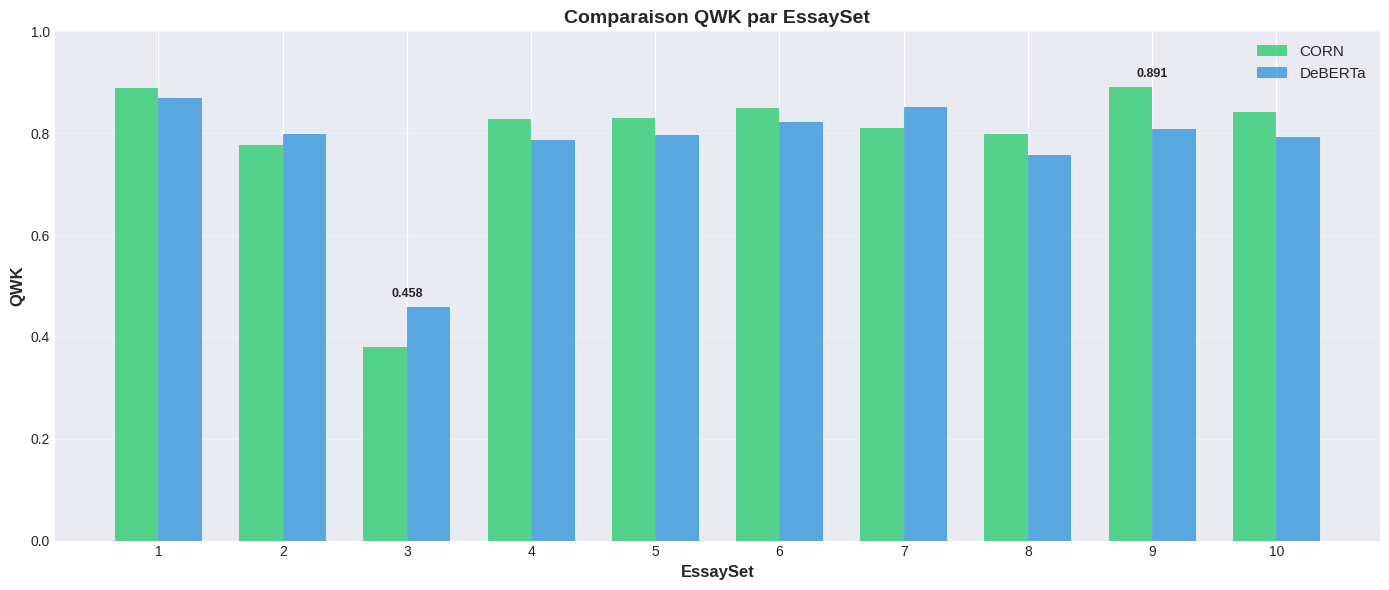

In [20]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 1 : Comparaison QWK par EssaySet
# ══════════════════════════════════════════════════════════

df_results = pd.DataFrame(results_by_es)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['corn_qwk'], width, label='CORN', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, df_results['deb_qwk'], width, label='DeBERTa', color='#3498db', alpha=0.8)

ax.set_xlabel('EssaySet', fontsize=12, fontweight='bold')
ax.set_ylabel('QWK', fontsize=12, fontweight='bold')
ax.set_title('Comparaison QWK par EssaySet', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['essay_set'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Annotations
for i, (c, d) in enumerate(zip(df_results['corn_qwk'], df_results['deb_qwk'])):
    if abs(c - d) > 0.05:  # Annoter seulement si différence significative
        winner_val = max(c, d)
        ax.text(i, winner_val + 0.02, f'{winner_val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


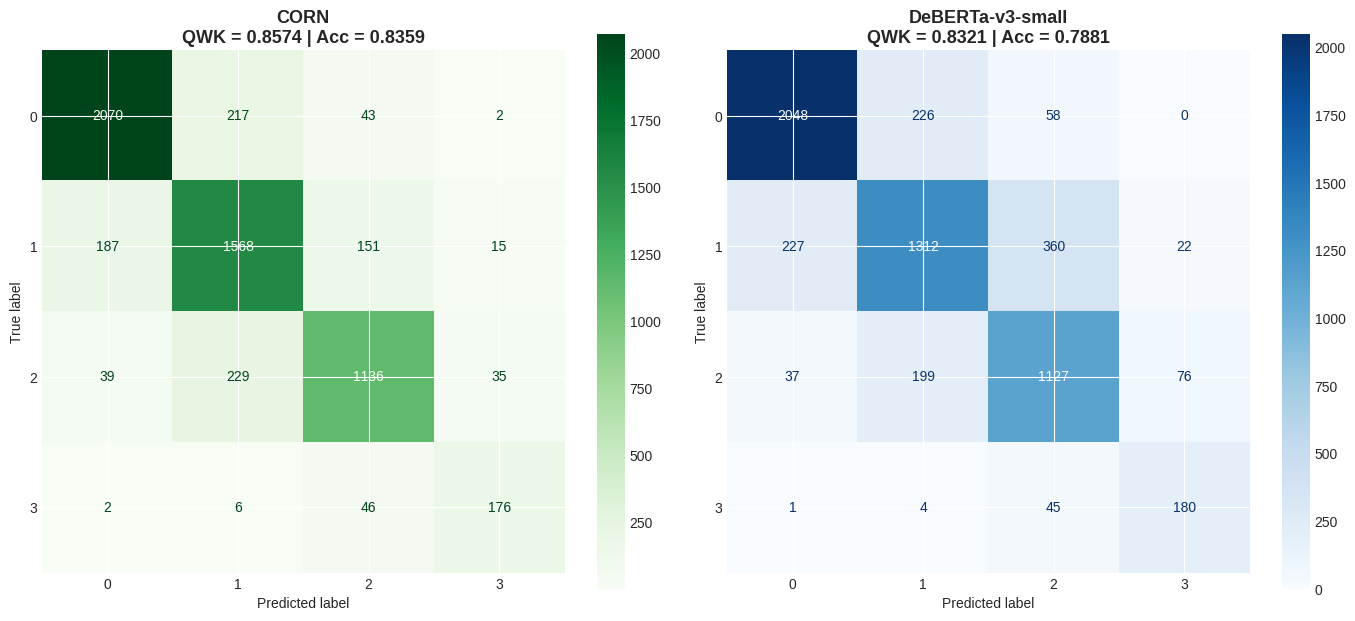


 Analyse des erreurs:

CORN        :  972 erreurs ( 16.4%) | Erreurs extrêmes (Δ≥2): 107
DeBERTa     : 1255 erreurs ( 21.2%) | Erreurs extrêmes (Δ≥2): 122


In [21]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 2 : Matrices de confusion côte à côte
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CORN
cm_corn = confusion_matrix(y_test, preds_corn_test, labels=[0,1,2,3])
disp_corn = ConfusionMatrixDisplay(cm_corn, display_labels=[0,1,2,3])
disp_corn.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title(f'CORN\nQWK = {qwk_corn:.4f} | Acc = {acc_corn:.4f}',
                  fontsize=13, fontweight='bold')

# DeBERTa
cm_deb = confusion_matrix(y_test, preds_deb_test, labels=[0,1,2,3])
disp_deb = ConfusionMatrixDisplay(cm_deb, display_labels=[0,1,2,3])
disp_deb.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'DeBERTa-v3-small\nQWK = {qwk_deb:.4f} | Acc = {acc_deb:.4f}',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyse des erreurs
print('\n Analyse des erreurs:\n')
for name, preds in [('CORN', preds_corn_test), ('DeBERTa', preds_deb_test)]:
    errors = preds != y_test
    extreme_errors = np.abs(preds - y_test) >= 2
    print(f'{name:12s}: {errors.sum():4d} erreurs ({errors.sum()/len(y_test)*100:5.1f}%) | '
          f'Erreurs extrêmes (Δ≥2): {extreme_errors.sum():3d}')


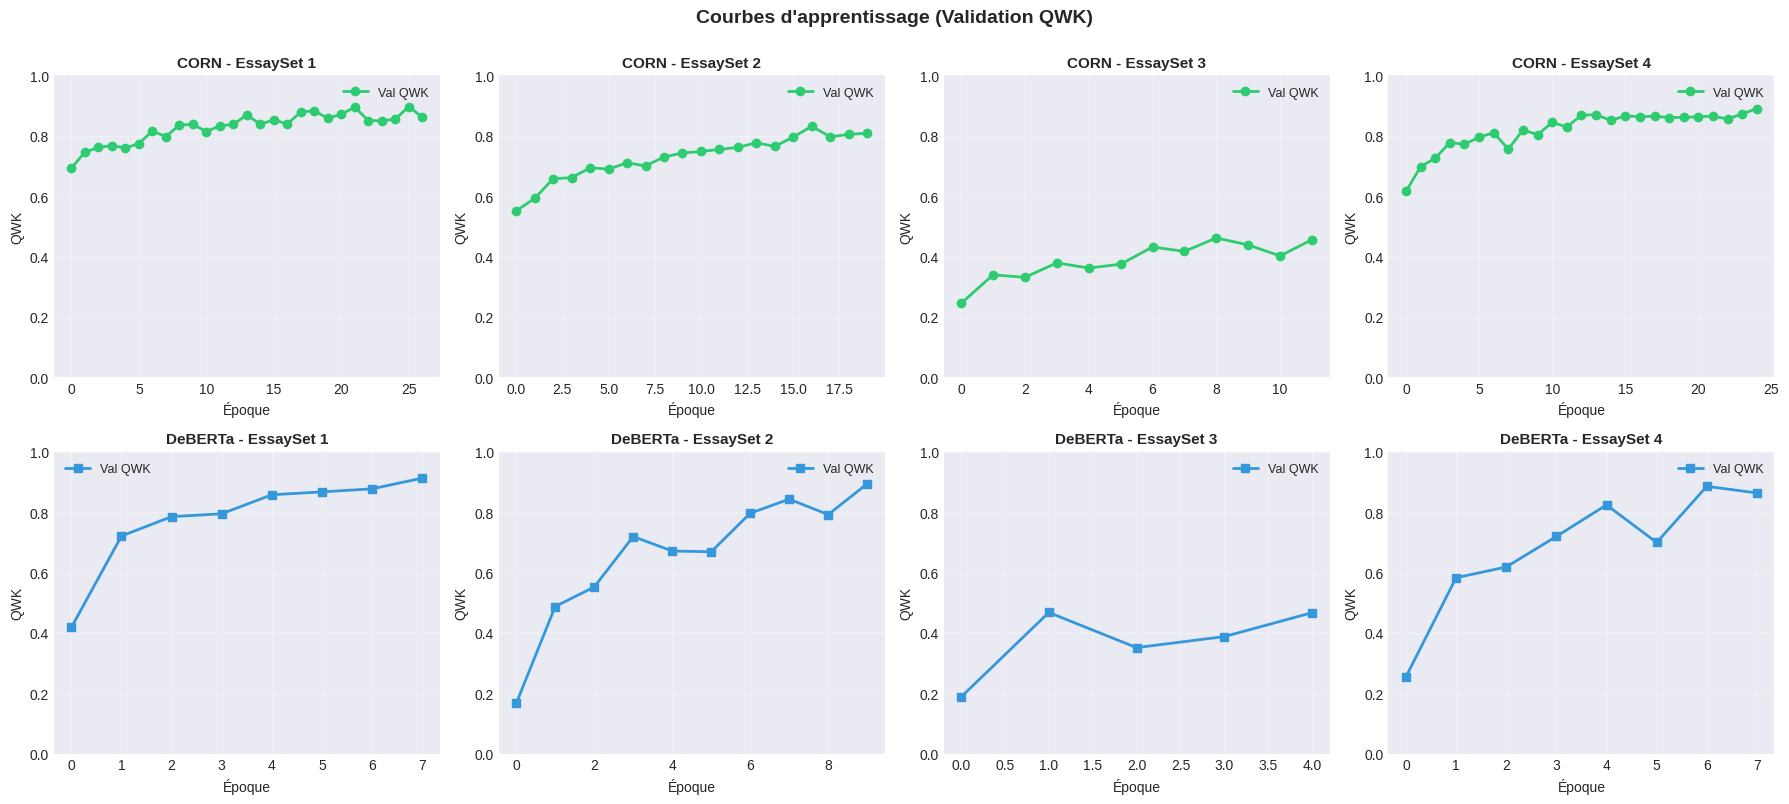

In [22]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 3 : Courbes d'entraînement
# ══════════════════════════════════════════════════════════

# Sélectionner 4 questions représentatives
selected_es = sorted(df_test['essay_set'].unique())[:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, es in enumerate(selected_es):
    # CORN
    if es in corn_models:
        _, hist_c, _, _ = corn_models[es]
        ax = axes[0, idx]
        ax.plot(hist_c['val_qwk'], marker='o', color='#2ecc71', linewidth=2, label='Val QWK')
        ax.set_title(f'CORN - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

    # DeBERTa
    if es in deberta_models:
        _, _, hist_d, _, _ = deberta_models[es]
        ax = axes[1, idx]
        ax.plot(hist_d['val_qwk'], marker='s', color='#3498db', linewidth=2, label='Val QWK')
        ax.set_title(f'DeBERTa - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

plt.suptitle('Courbes d\'apprentissage (Validation QWK)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


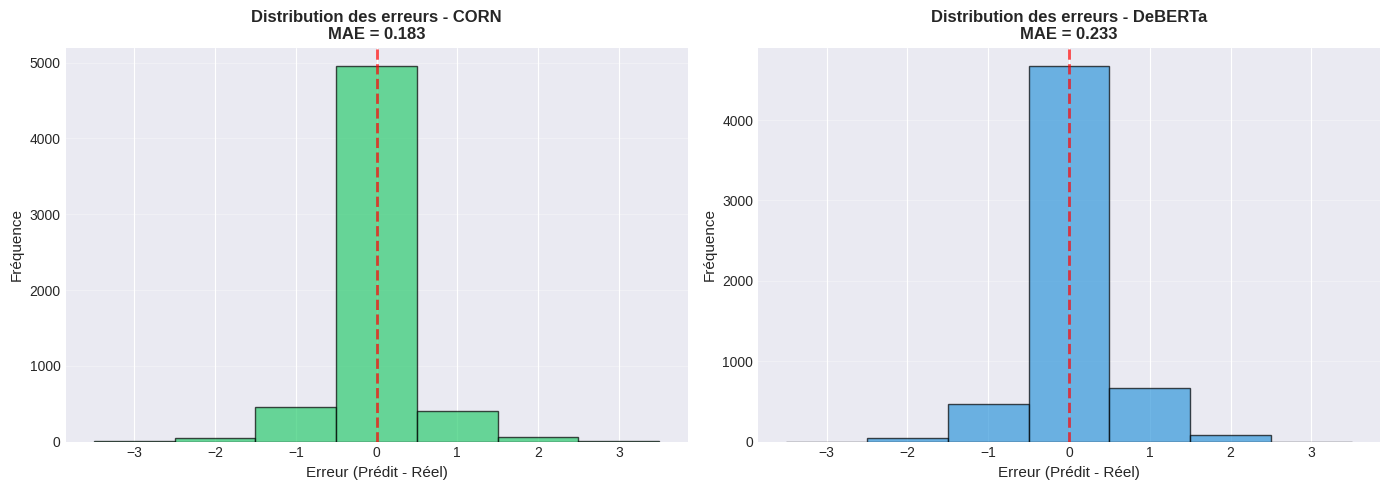

In [23]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 4 : Distribution des erreurs
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Erreurs CORN
errors_corn = preds_corn_test - y_test
axes[0].hist(errors_corn, bins=np.arange(-3.5, 4.5, 1), color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[0].set_ylabel('Fréquence', fontsize=11)
axes[0].set_title(f'Distribution des erreurs - CORN\nMAE = {np.abs(errors_corn).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].grid(axis='y', alpha=0.3)

# Erreurs DeBERTa
errors_deb = preds_deb_test - y_test
axes[1].hist(errors_deb, bins=np.arange(-3.5, 4.5, 1), color='#3498db', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title(f'Distribution des erreurs - DeBERTa\nMAE = {np.abs(errors_deb).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


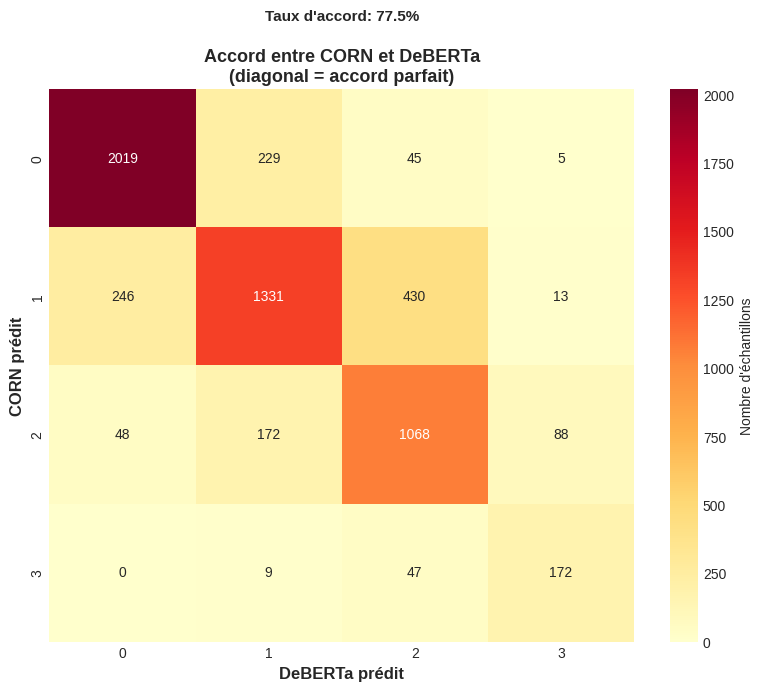

In [24]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 5 : Heatmap de comparaison
# ══════════════════════════════════════════════════════════

# Matrice : combien de fois CORN et DeBERTa prédisent la même chose
agreement_matrix = confusion_matrix(preds_corn_test, preds_deb_test, labels=[0,1,2,3])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(agreement_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3],
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_xlabel('DeBERTa prédit', fontsize=12, fontweight='bold')
ax.set_ylabel('CORN prédit', fontsize=12, fontweight='bold')
ax.set_title('Accord entre CORN et DeBERTa\n(diagonal = accord parfait)',
             fontsize=13, fontweight='bold')

# Taux d'accord
agreement_rate = (preds_corn_test == preds_deb_test).sum() / len(y_test)
ax.text(2, -0.5, f'Taux d\'accord: {agreement_rate*100:.1f}%',
        fontsize=11, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()


## **12. Rapport de classification détaillé**


In [25]:
print('='*70)
print(' RAPPORT DE CLASSIFICATION DÉTAILLÉ')
print('='*70)

print('\n🔹 CORN:\n')
print(classification_report(y_test, preds_corn_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))

print('\n🔹 DeBERTa-v3-small:\n')
print(classification_report(y_test, preds_deb_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))


 RAPPORT DE CLASSIFICATION DÉTAILLÉ

🔹 CORN:

              precision    recall  f1-score   support

     Score 0       0.90      0.89      0.89      2332
     Score 1       0.78      0.82      0.80      1921
     Score 2       0.83      0.79      0.81      1439
     Score 3       0.77      0.77      0.77       230

    accuracy                           0.84      5922
   macro avg       0.82      0.81      0.82      5922
weighted avg       0.84      0.84      0.84      5922


🔹 DeBERTa-v3-small:

              precision    recall  f1-score   support

     Score 0       0.89      0.88      0.88      2332
     Score 1       0.75      0.68      0.72      1921
     Score 2       0.71      0.78      0.74      1439
     Score 3       0.65      0.78      0.71       230

    accuracy                           0.79      5922
   macro avg       0.75      0.78      0.76      5922
weighted avg       0.79      0.79      0.79      5922



## **13. Conclusion**

### Points clés

1. **Entraînement par question** : Permet de respecter l'hétérogénéité des sujets (science vs littérature, rubrics différentes)

2. **CORN (Régression ordinale)** :
   - Exploite la structure ordinale des scores
   - Réduit les erreurs extrêmes (0↔3)
   - Entraînement rapide avec SBERT figé

3. **DeBERTa-v3-small** :
   - Encodeur adapté à la tâche via fine-tuning
   - Capture mieux les nuances linguistiques
   - Plus coûteux en temps et mémoire

### Recommandations

- Si **temps/mémoire limités** → CORN
- Si **performance maximale recherchée** → DeBERTa (ou ensemble des deux)
- Pour **production** → Considérer un ensemble pondéré pour combiner les forces

### Perspectives d'amélioration

- **DeBERTa-v3-base** (184M params) pour gain de performance
- **Similarité avec réponse de référence** comme feature supplémentaire
- **Data augmentation** (paraphrase) pour classes déséquilibrées
- **Cross-validation** pour estimation plus robuste
